In [1]:
import scipy.special as sp
import scipy.integrate as integrate
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
from scipy.integrate import simpson

In [ ]:


theta_00=9*np.pi/128 #first initial theta that is not zero.
x_0=[theta_00+9*np.pi/(100*128),0] #inital vector [theta_0, omega_0] for each trajectory.
n_trajectories=15 #number of trajectories
omega_0=.25 #contant equal to sqrt(g/l) where l is pendulum length.
t=1600
tt=.125/2*(np.array(range(0,t,4))) #Make time range into numpy array from 0 to 100s
F_theta=np.zeros([np.size(tt)]) #Initalize vector
F_omega=np.zeros([np.size(tt)]) #Initalize vector
F_omegadot=np.zeros([np.size(tt)]) #Initalize vector
print(tt)

[ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25 11.5  11.75
 12.   12.25 12.5  12.75 13.   13.25 13.5  13.75 14.   14.25 14.5  14.75
 15.   15.25 15.5  15.75 16.   16.25 16.5  16.75 17.   17.25 17.5  17.75
 18.   18.25 18.5  18.75 19.   19.25 19.5  19.75 20.   20.25 20.5  20.75
 21.   21.25 21.5  21.75 22.   22.25 22.5  22.75 23.   23.25 23.5  23.75
 24.   24.25 24.5  24.75 25.   25.25 25.5  25.75 26.   26.25 26.5  26.75
 27.   27.25 27.5  27.75 28.   28.25 28.5  28.75 29.   29.25 29.5  29.75
 30.   30.25 30.5  30.75 31.   31.25 31.5  31.75 32.   32.25 32.5  32.75
 33.   33.25 33.5  33.75 34.   34.25 34.5  34.75 35.   35.25 35.5  35.75
 36.   36.25 36.5  36.75 37.   37.25 37.5  37.75 38.   38.25 38.5  38.75
 39.   39.25 39.5  39.75 40.   40.25 40.5  40.75 41

In [7]:
def fx(t,x,omega_0): #define integrator for pendulum ODE to find omega
    return np.array([x[1],-omega_0**2*np.sin(x[0])])

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:39: UserWarning: The following arguments have no effect for a chosen solver: `vectorize`.
  warn("The following arguments have no effect for a chosen solver: {}."
/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


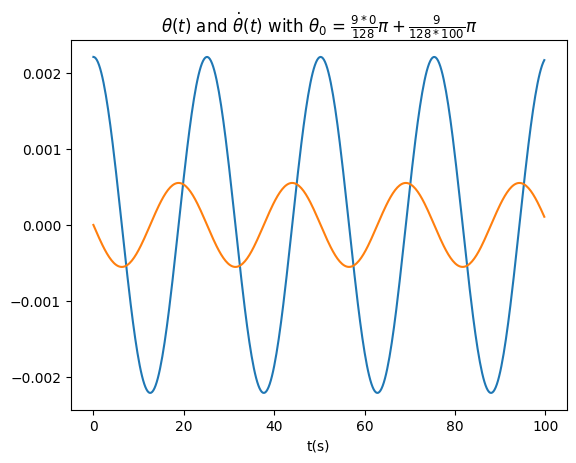

0.0π
Percent Error:


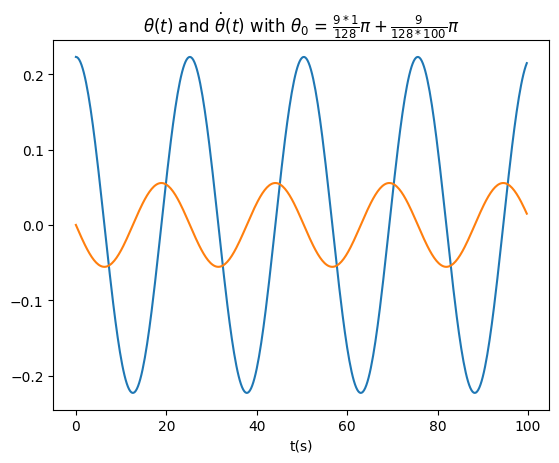

0.0703125π
Percent Error:


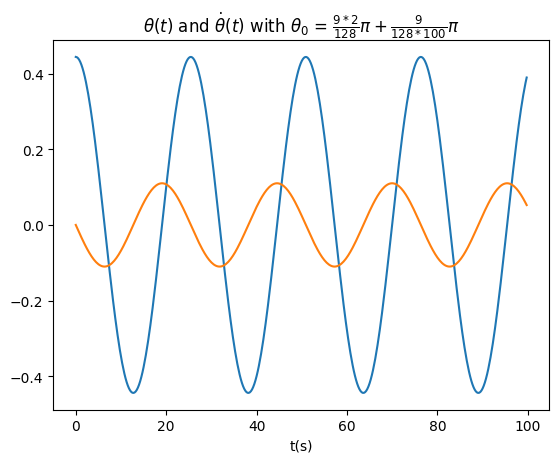

0.140625π
Percent Error:


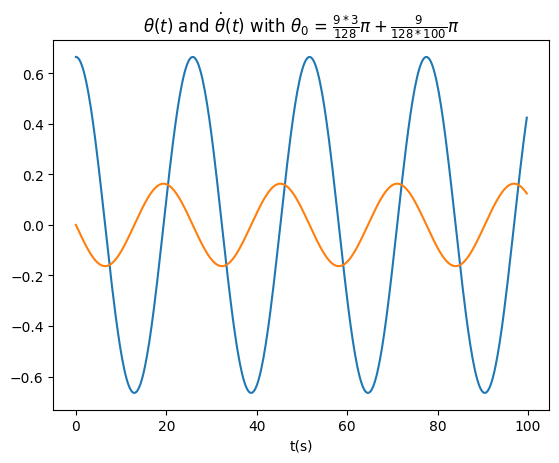

0.2109375π
Percent Error:


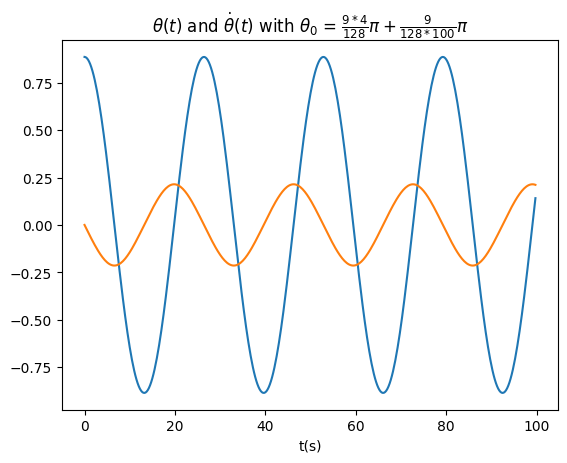

0.28125π
Percent Error:


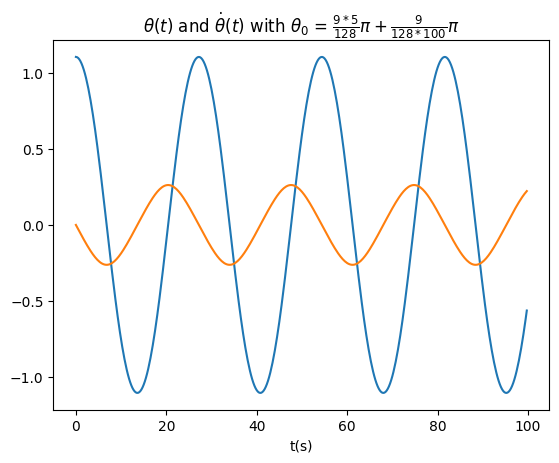

0.3515625π
Percent Error:


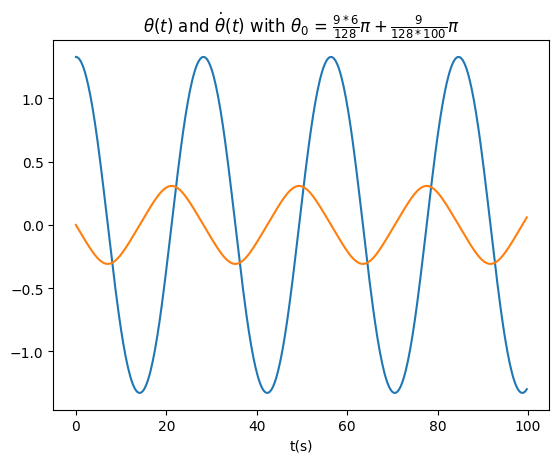

0.421875π
Percent Error:


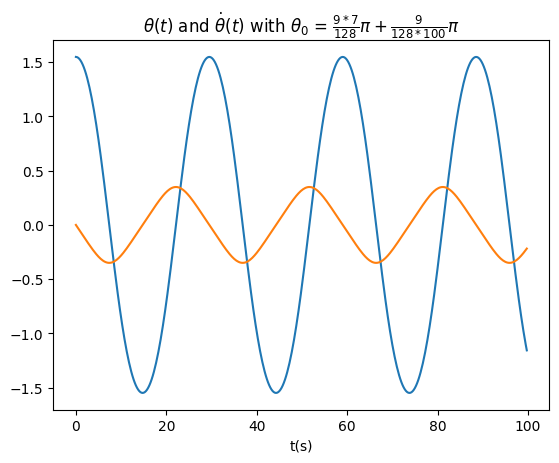

0.4921875π
Percent Error:


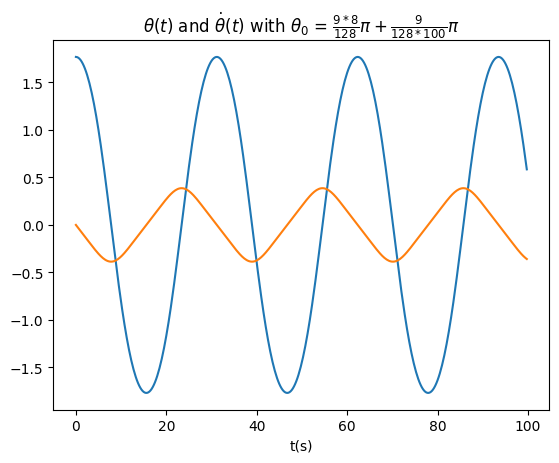

0.5625π
Percent Error:


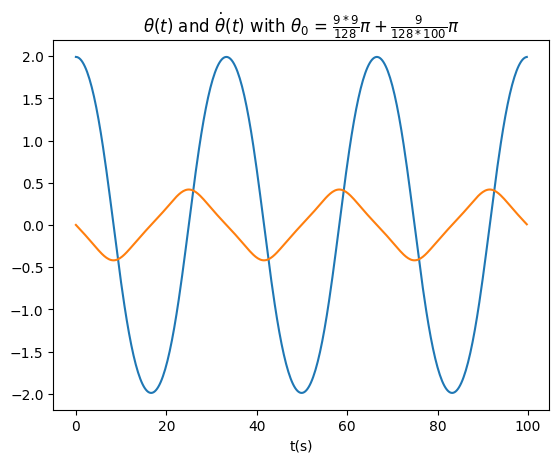

0.6328125π
Percent Error:


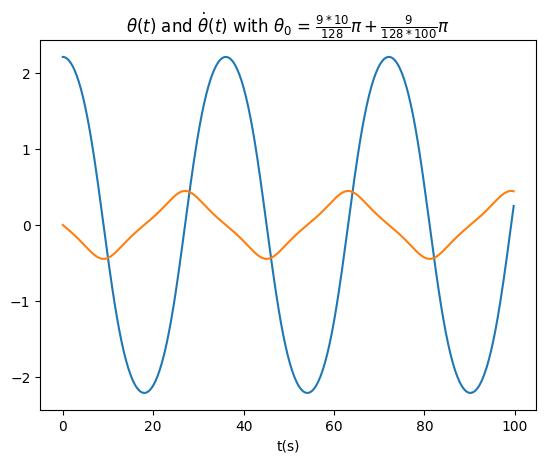

0.703125π
Percent Error:


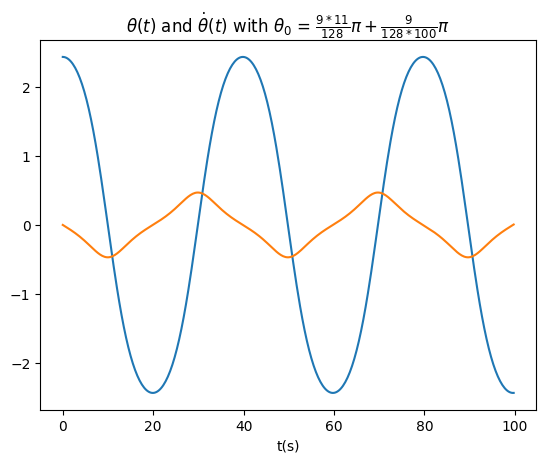

0.7734375π
Percent Error:


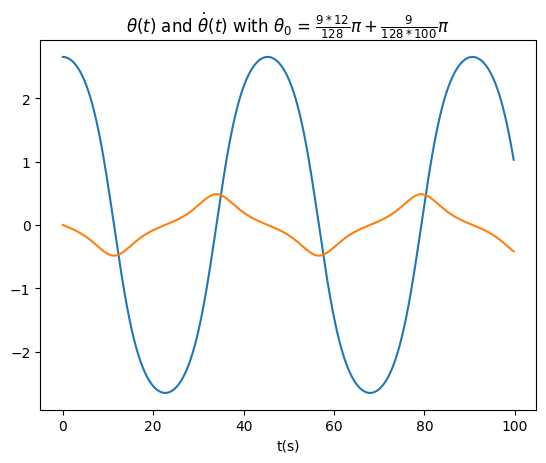

0.84375π
Percent Error:


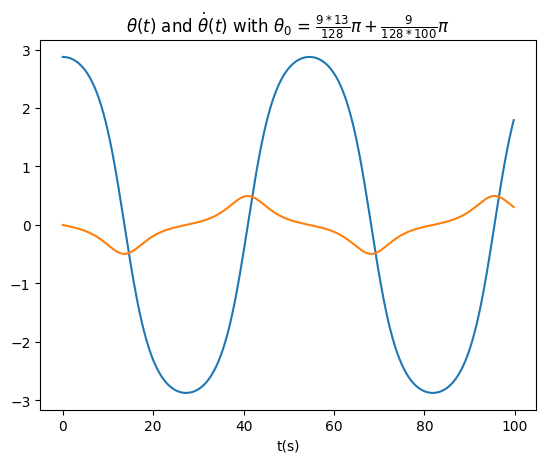

0.9140625π
Percent Error:


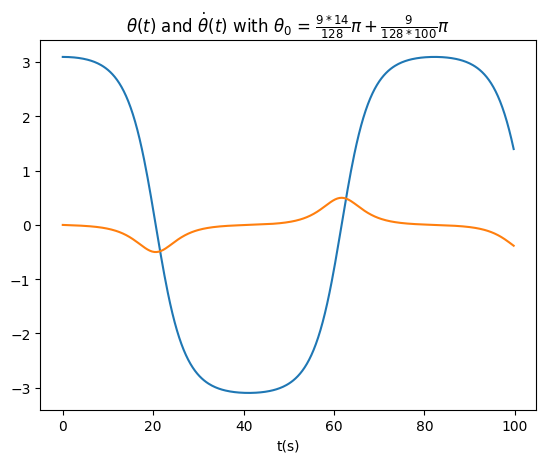

0.984375π
Percent Error:


In [38]:
#Create synthetic data for the simnple pendulum
Gmatrix=[]
F_1=np.zeros(np.size(tt))
F_14=np.zeros(np.size(tt))
for i in range(0,n_trajectories):
    theta_0=i*theta_00+9*np.pi/(100*128) #intial theta for each trajectory
    m=np.sin(theta_0/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #parameter for each trajectory
    xt=solve_ivp(fx,t_span=(tt[0],tt[-1]),t_eval=tt,y0=([theta_0,0]),args=(omega_0,),vectorize=True, rtol=1e-20,method='DOP853')
    for j in range(np.size(tt)):
        F_theta[j]=2*np.arcsin(np.sin(theta_0/2)*sp.ellipj(K-omega_0*tt[j],(np.sin(theta_0/2)**2))[0])
        if i==1:
            F_1[j]=F_theta[j]
        if i==14:
            F_14[j]=F_theta[j]
        F_omega[j]=xt.y[1][j] #use numerical solution for omega[j]
        F_omegadot[j]=-omega_0**2*np.sin(F_theta[j])
   
    theta0_str = f"$\\frac{{9 * {i}}}{{128}}\\pi+\\frac{{9}}{{128*100}}\\pi$"
    plt.title(rf"$\theta(t)$ and $\dot{{\theta}}(t)$ with $\theta_0$ = {theta0_str}")
    plt.plot(tt,F_theta)
    plt.plot(tt,F_omega)
    #plt.plot(tt,F_omegadot)
    plt.xlabel('t(s)')
    plt.show()
    print(f"{9*i/128}π")
    print("Percent Error:")
    #print(np.linalg.norm((xt.y[0,:] - F_theta[:]))/np.linalg.norm(F_theta[:])*100)
    #print(np.linalg.norm((xt.y[0] - F_theta))/np.linalg.norm(F_theta)*100)
    G=np.column_stack([F_theta[:],F_omega[:]])
    Gmatrix.append(G) #create data matrix with number of samples, n_samples for each trajectory
Gmatrix=np.squeeze(np.stack(Gmatrix)) #Combine all trajectory data into one numpy array

In [11]:
theGamma = 10

In [ ]:
# TODO: Vectorize (and print the time for 1000 dimensional x, with as many as 10000 x and 10000 y)
# You will see orders of magnitude difference in run time.
def k(x,y,gamma=theGamma): #Define Guassian kernel
     dist=sum(x**2)+sum(y**2)-2*np.dot(x,y)
     return np.exp(-gamma*dist)
   

In [ ]:
#Split trajectories into len(tt)-1 segments
M=np.zeros([n_trajectories*(len(tt)-1),n_trajectories*(len(tt)-1)]) #Initialize M
for i in range(n_trajectories):
    for j in range(n_trajectories):
      for m in range(len(tt)-1):
        for n in range(len(tt)-1):
          k1 = k(Gmatrix[i,m,:],Gmatrix[j,n,:],gamma=theGamma)
          k2 = k(Gmatrix[i,m,:],Gmatrix[j,n+1,:],gamma=theGamma)
          k3 = k(Gmatrix[i,m+1,:],Gmatrix[j,n,:],gamma=theGamma)
          k4 = k(Gmatrix[i,m+1,:],Gmatrix[j,n+1,:],gamma=theGamma)
          M[m+(len(tt)-1)*i,n+(len(tt)-1)*j]=((tt[1]-tt[0])**2/4)*(k1+k2+k3+k3)

In [ ]:
d=2
#delta=(Gmatrix[:,-1]-Gmatrix[:,0]).reshape(d*n_trajectories,1)
delta = np.zeros([d*n_trajectories*(len(tt)-1)])
for i in range(n_trajectories):
  for m in range(len(tt)-1):
    delta[(m+(len(tt)-1)*i)*d:(m+(len(tt)-1)*i+1)*d]=Gmatrix[i,m+1,:]-Gmatrix[i,m,:]

Marray=np.kron(M,np.identity(d)) #Create matrix for vector valued kernel usinbg kronecker product

In [15]:

l=.0000005 #regularization hyperparmeter.
Mplus=Marray+l*n_trajectories*(len(tt)-1)*np.identity(d*n_trajectories*(len(tt)-1)) #create modified M.
alpha=np.linalg.solve(Mplus,delta)#solve linear system for alpha.
#alphamatrix=alpha.reshape(n_trajectories*(len(tt)-1),d,order='F') #reshape alpha so that alpha[i] has is 1xd

In [16]:
slopes = (Gmatrix[:,1:,:] - Gmatrix[:,:-1,:])/(tt[1]-tt[0])

In [ ]:
#function for finding optimal slope field for each trajectory point and
#at each time point as determined by MOCK
def fstar(t,y,Gmatrix,alpha,tspan,d):
    matrix = np.zeros([d,d*n_trajectories*(len(tt)-1)])
    for i in range(n_trajectories):
      for m in range(len(tt)-1):
        matrix[:,(m+(len(tt)-1)*i)*d:(m+(len(tt)-1)*i + 1)*d] = (tspan/2)*(k(y,Gmatrix[i,m,:])+k(y,Gmatrix[i,m+1,:]))*np.identity(d)
    return matrix@alpha

In [ ]:
#predicted slope field matrix
predicted_matrix = np.zeros((slopes.shape[0],len(tt)-1,slopes.shape[-1]))
for i in range(n_trajectories):
  for m in range(len(tt)-1):
    y = Gmatrix[i,m,:]
    predicted_slope = fstar(0,y,Gmatrix,alpha,tt[1]-tt[0],d)
    predicted_matrix[i,m,:] = predicted_slope


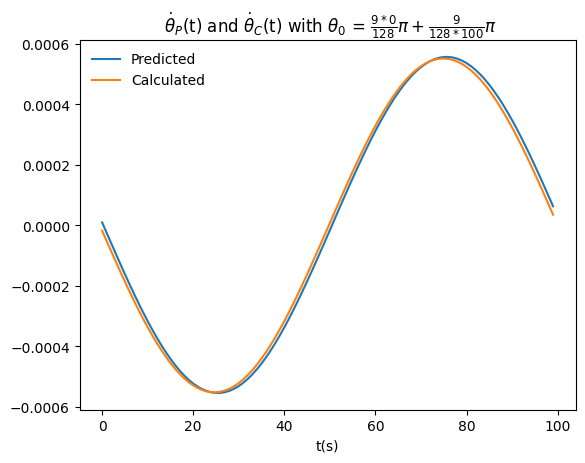

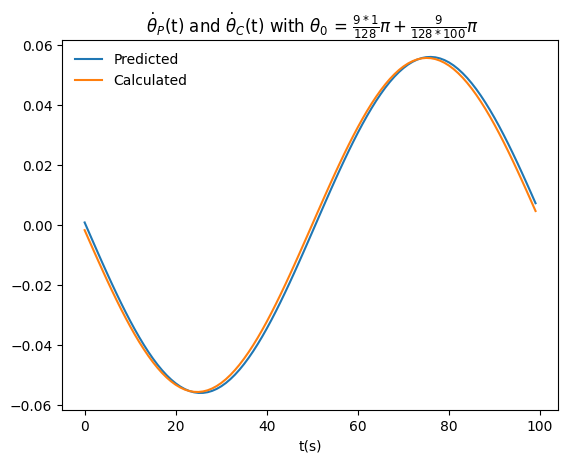

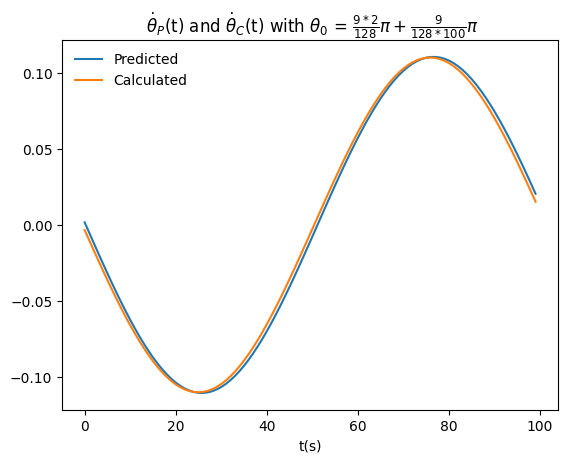

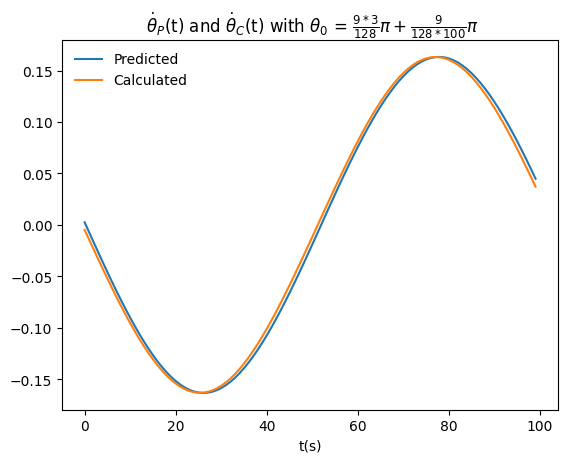

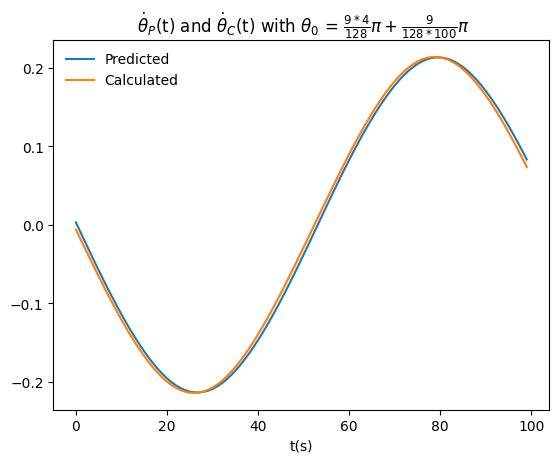

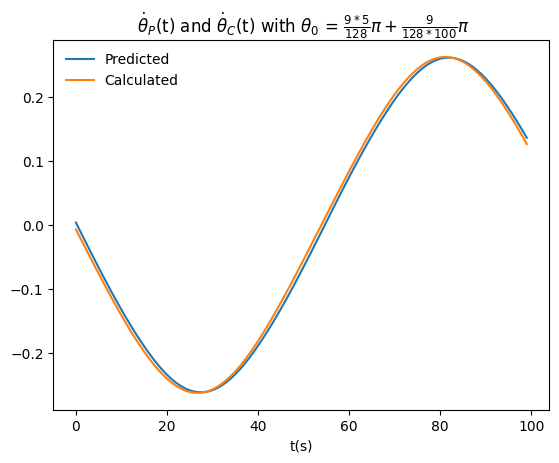

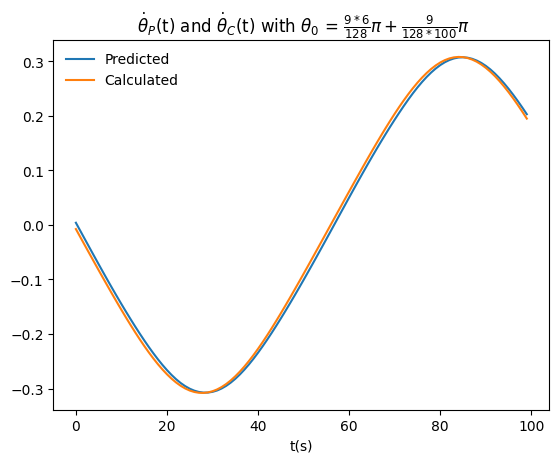

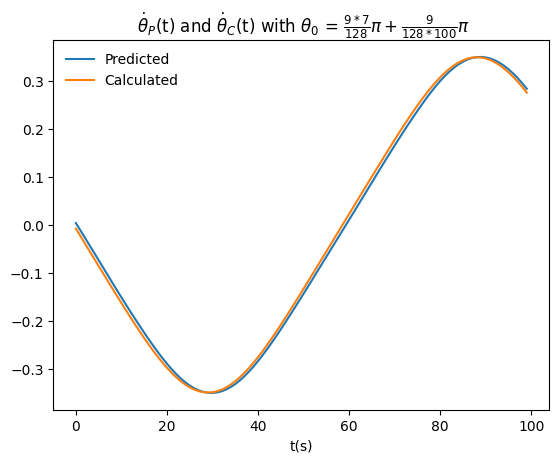

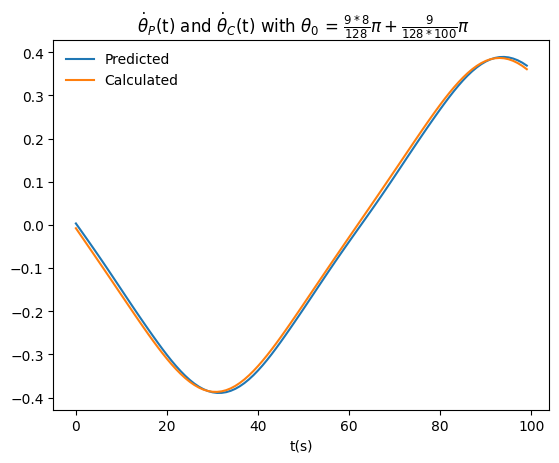

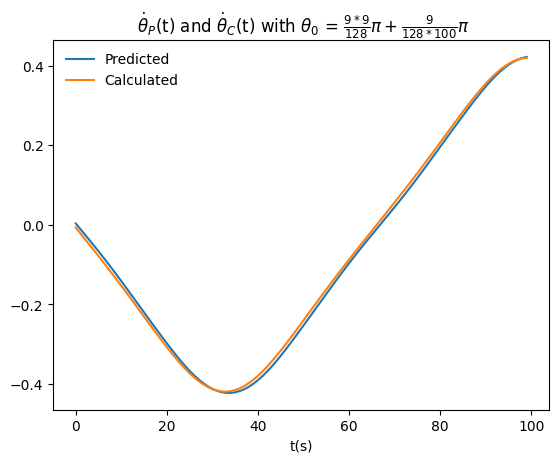

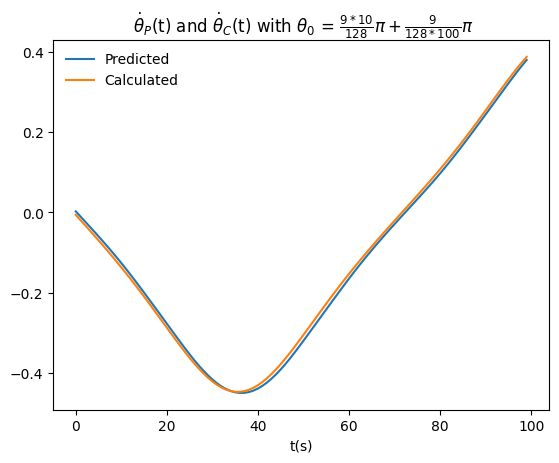

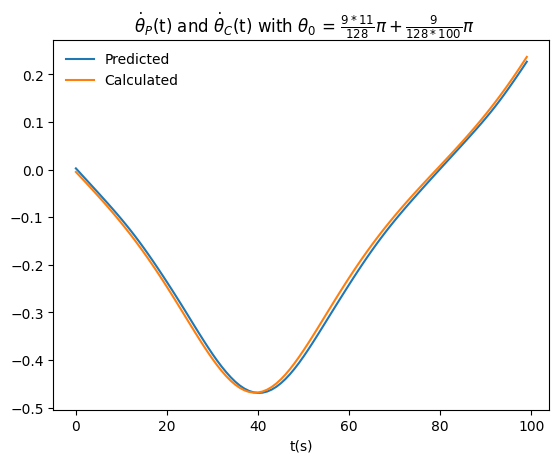

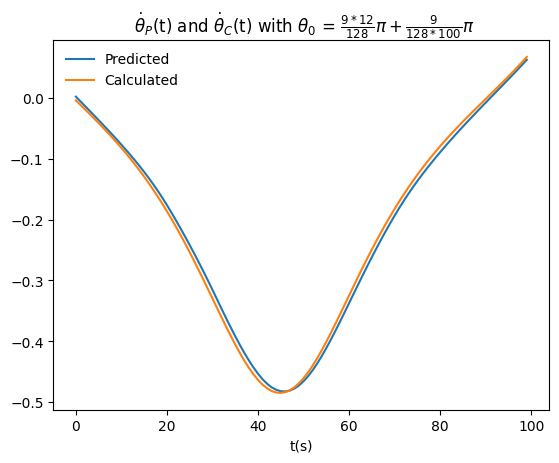

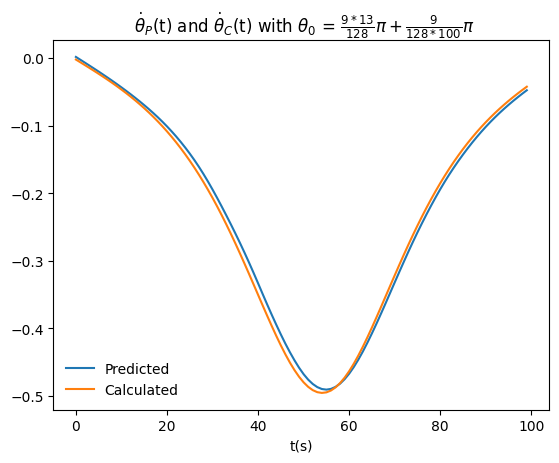

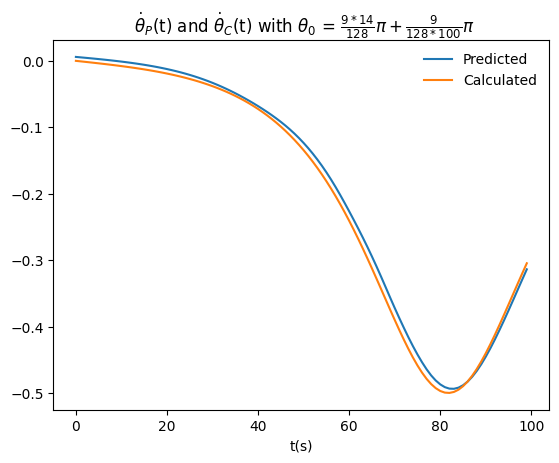

In [ ]:
#Plot training set first derivative
for i in range(n_trajectories):
    plt.plot(predicted_matrix[i, :100, 0], label='Predicted')
    plt.plot(slopes[i,:100,0], label='Calculated')
    theta0_str = f"$\\frac{{9 * {i}}}{{128}}\\pi+\\frac{{9}}{{128*100}}\\pi$"
    theta_P = r"$\dot{\theta}_P$"
    theta_C = r"$\dot{\theta}_C$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
    plt.xlabel("t(s)")
    plt.legend(loc='best', frameon=False)
    plt.show()

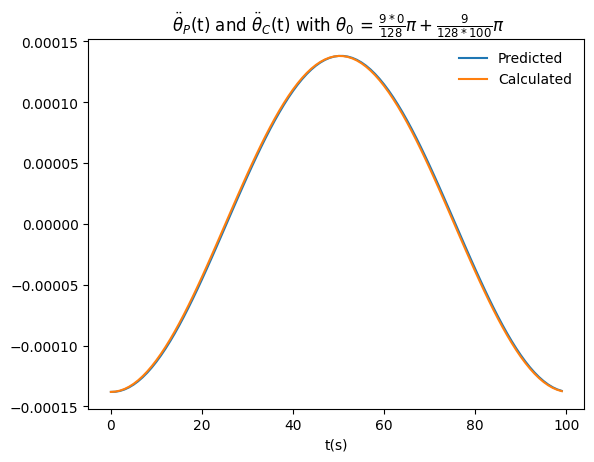

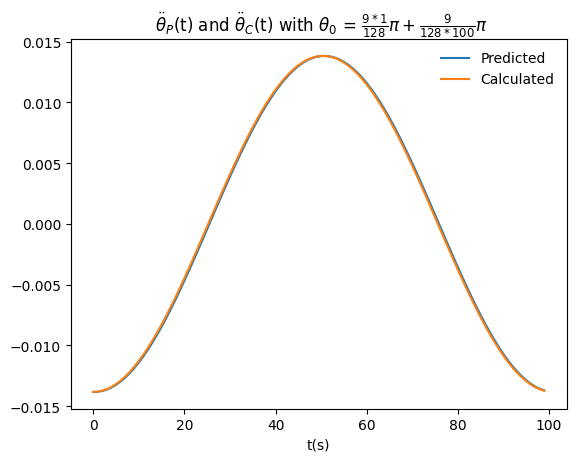

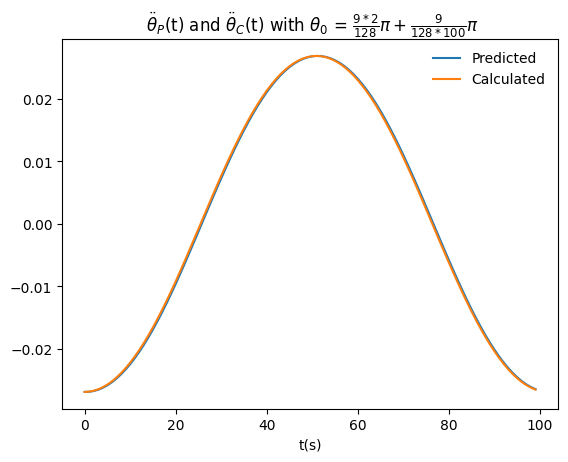

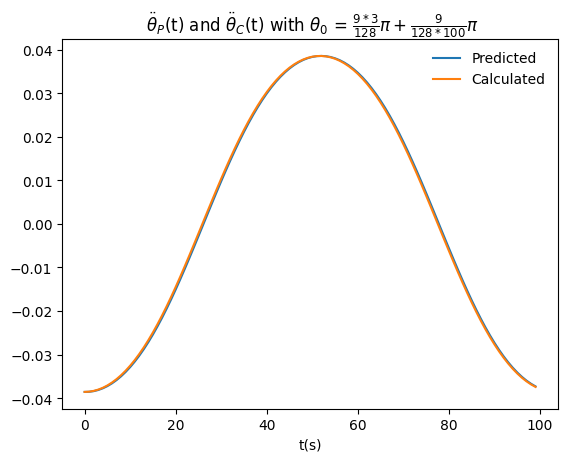

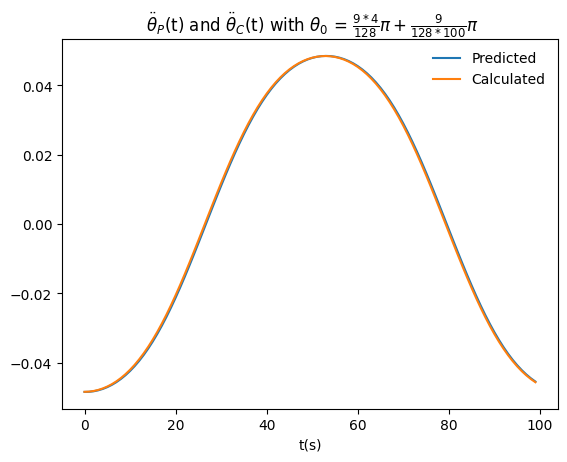

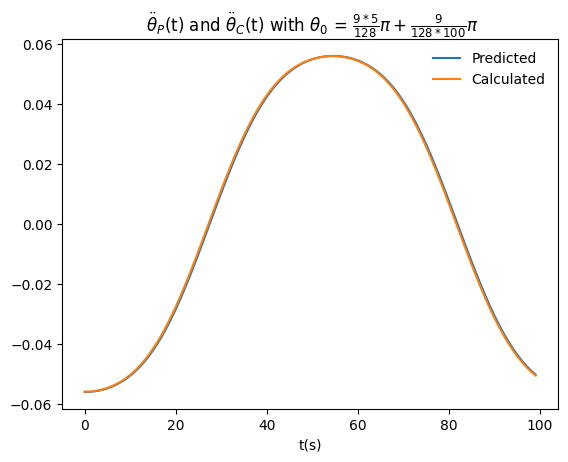

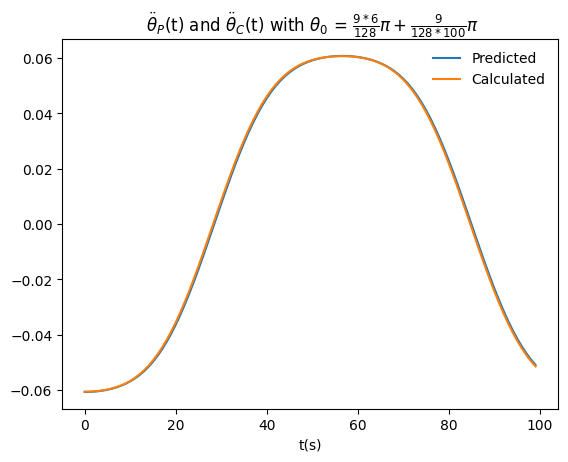

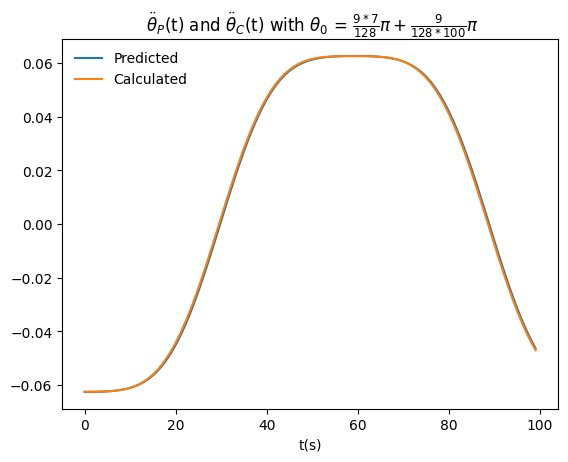

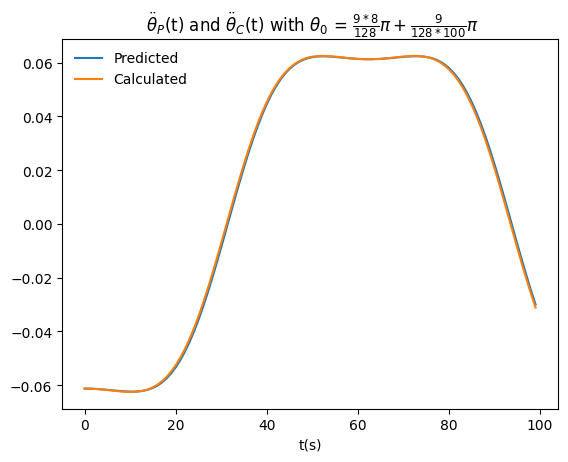

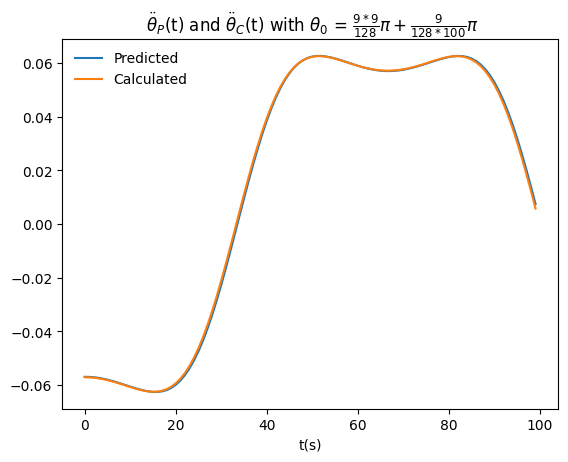

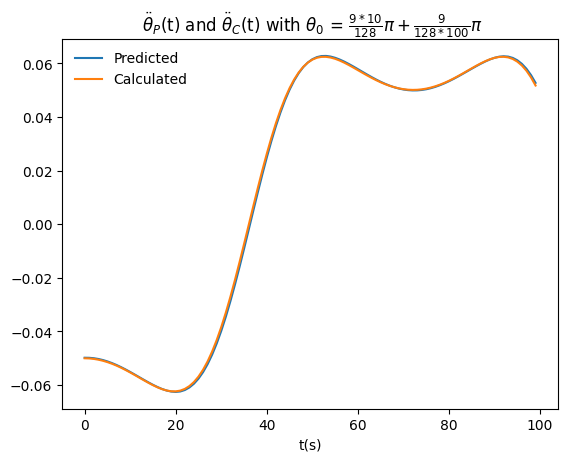

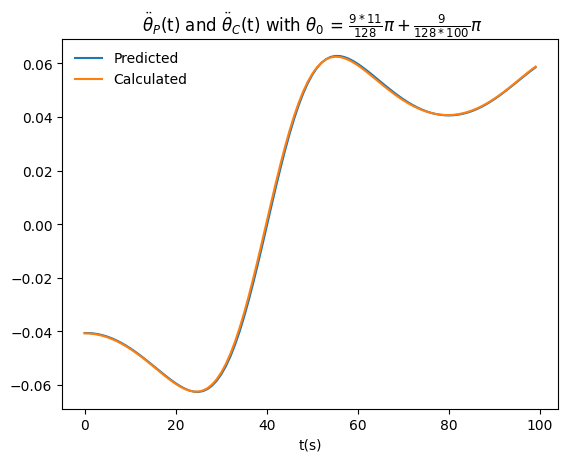

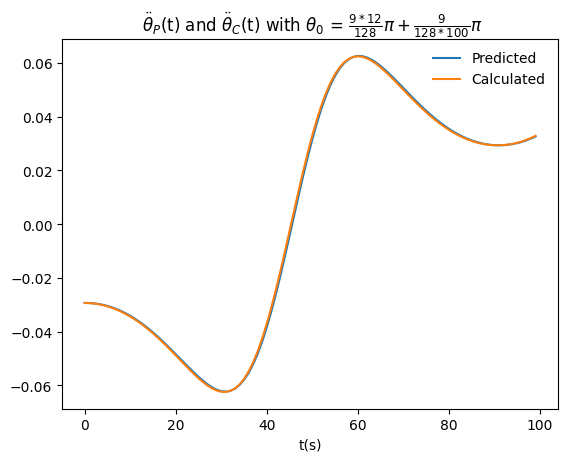

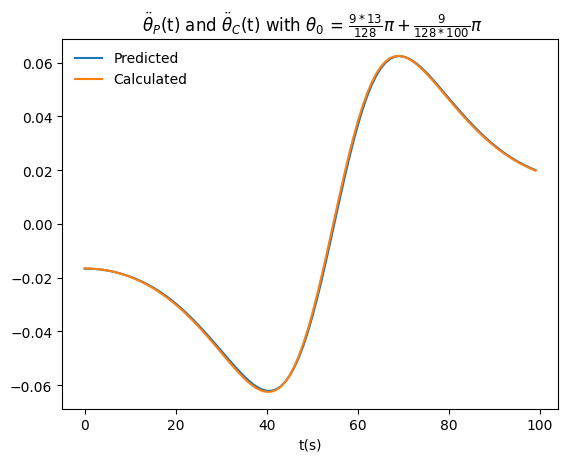

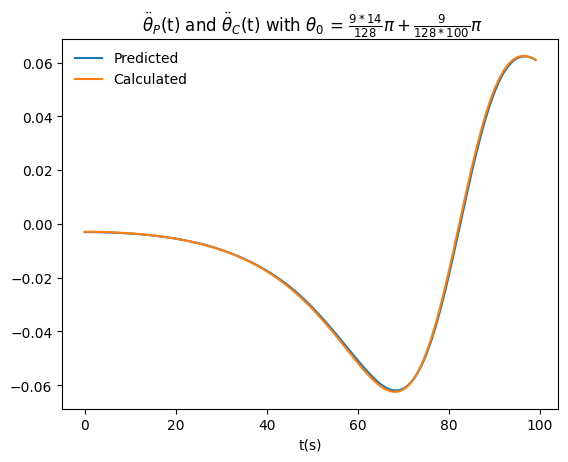

In [ ]:
#Plot training set second derivative
for i in range(n_trajectories):
    plt.plot(predicted_matrix[i, :100, 1], label='Predicted')
    plt.plot(-omega_0**2 * np.sin(Gmatrix[i, :100, 0]), label='Calculated')

    theta0_str = f"$\\frac{{9 * {i}}}{{128}}\\pi+\\frac{{9}}{{128*100}}\\pi$"
    theta_P = r"$\ddot{\theta}_P$"
    theta_C = r"$\ddot{\theta}_C$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")

    plt.xlabel("t(s)")
    plt.legend(loc='best', frameon=False)
    plt.show()

In [21]:
y_0=Gmatrix[:,0,:]

In [ ]:
#Numerically integrate to find MOCK predictions for theta(t)
sol=np.zeros([n_trajectories,len(tt),d])
for i in range(n_trajectories):
#stop=2
#for i in range(stop):
  trajs=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=y_0[i,:],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
  sol[i,:]=(trajs.y).T
 

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


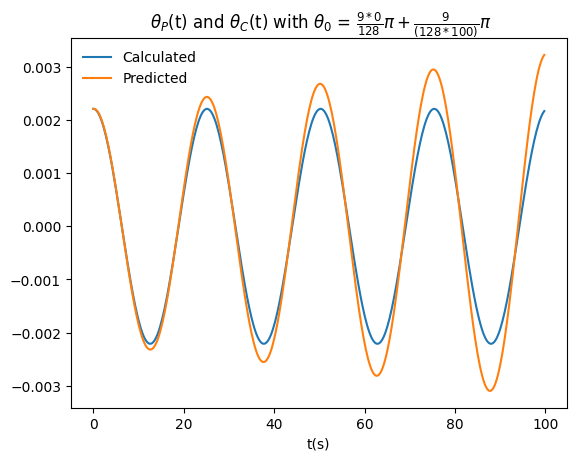

0.000703125π


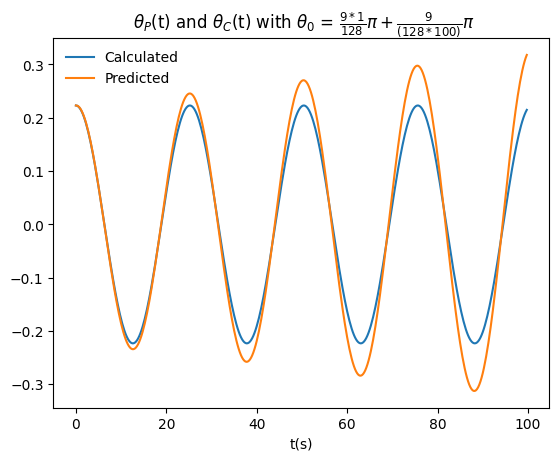

0.071015625π


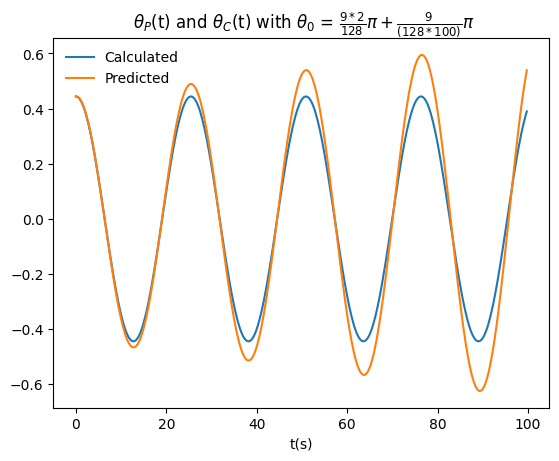

0.141328125π


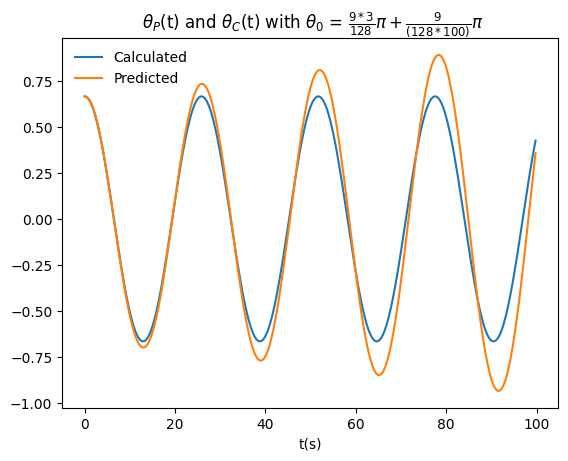

0.211640625π


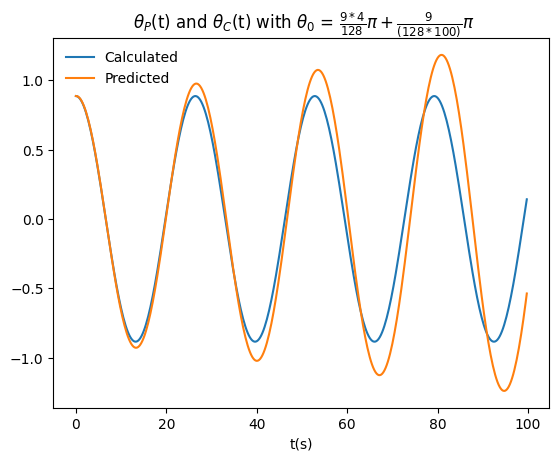

0.281953125π


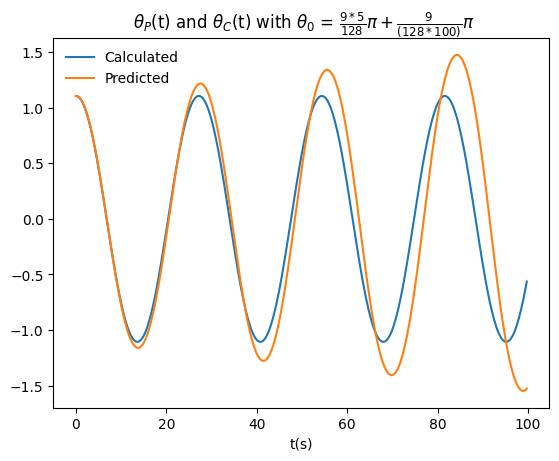

0.352265625π


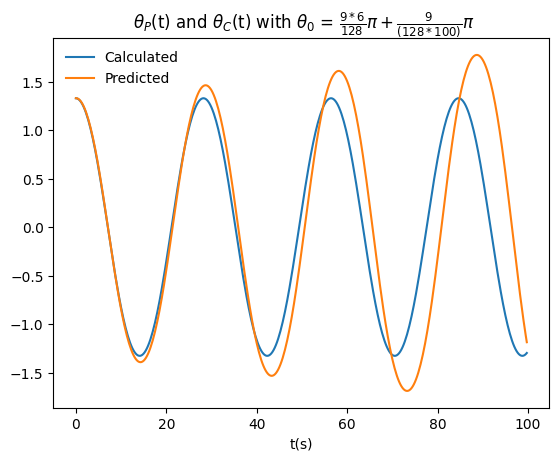

0.422578125π


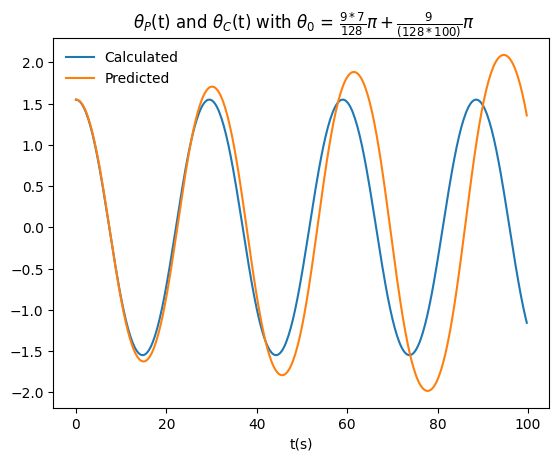

0.492890625π


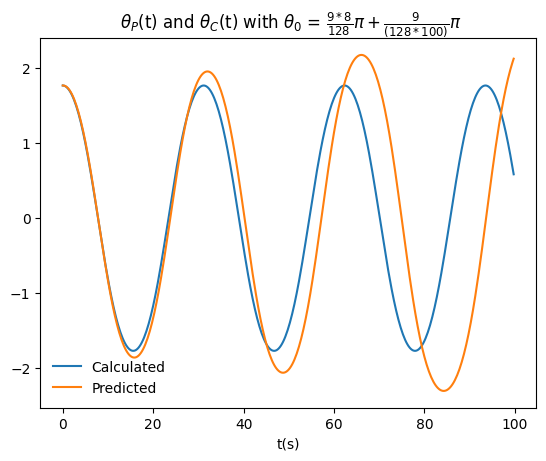

0.563203125π


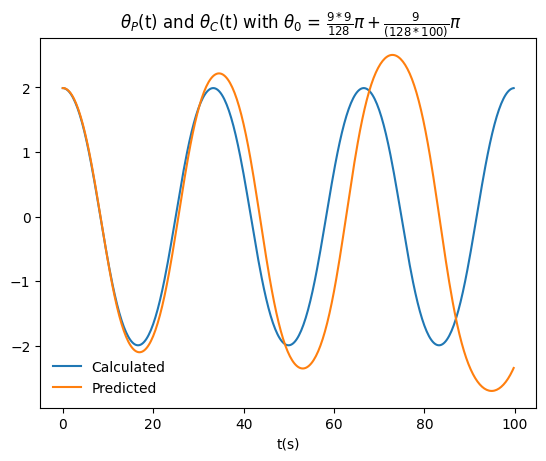

0.633515625π


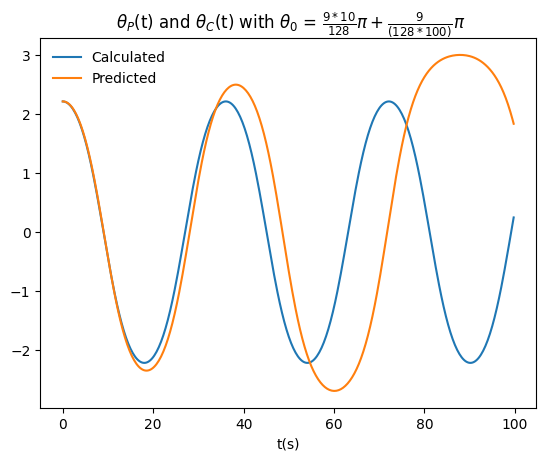

0.703828125π


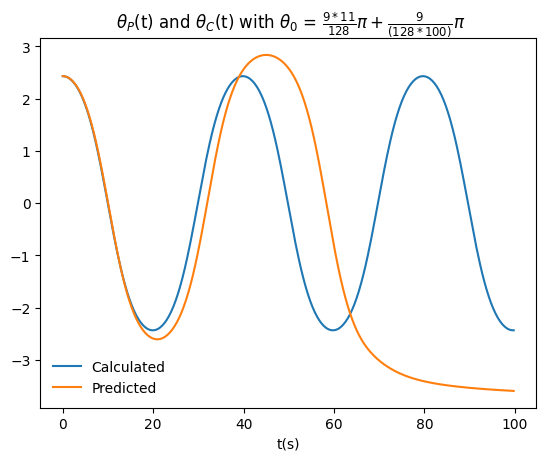

0.774140625π


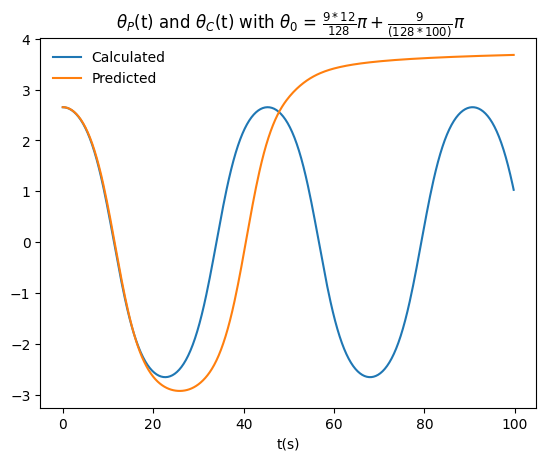

0.844453125π


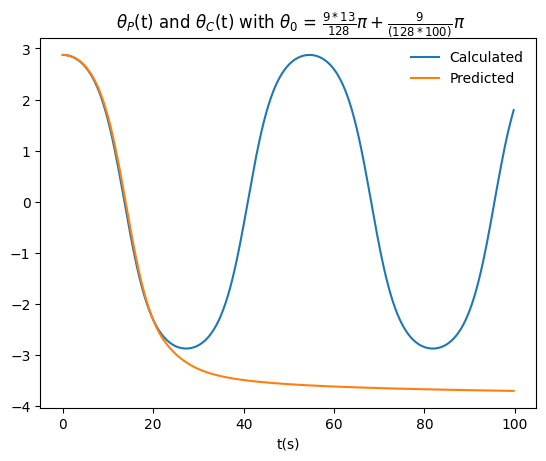

0.914765625π


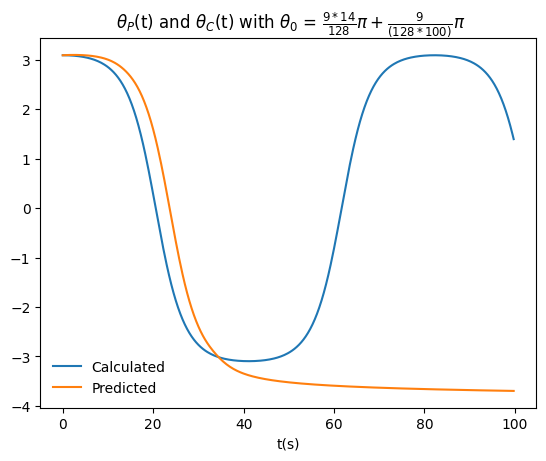

0.985078125π


In [ ]:
#Plot theta(t) for training set
for i in range(n_trajectories):

  plt.plot(tt,Gmatrix[i,:,0],label='Calculated')
  plt.plot(tt,sol[i,:,0],label='Predicted')
  theta0_str = f"$\\frac{{9 * {i}}}{{128}}\\pi+\\frac{{9}}{{(128*100)}}\\pi$"
  theta_P = r"${\theta}_P$"
  theta_C = r"${\theta}_C$"
  plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
  plt.xlabel('t(s)')
  plt.legend(loc='best',frameon=False)
  plt.show()
  print(f"{9*i/128+9/(128*100)}π")

In [ ]:
#Create five random starting points for test set
tn=5
testy_0=np.column_stack([np.pi*np.random.uniform(0,1,tn).T,np.zeros([tn,1])])
trajs_A=np.zeros(len(tt))

In [25]:
tn=5
testy_0=np.array([[3.1178716 , 0.        ],
       [1.95417974, 0.        ],
       [0.05323808, 0.        ],
       [2.15519758, 0.        ],
       [0.23792941, 0.        ]])

In [ ]:
#Numerically integrate to find theta(t)
sol=np.zeros([tn,len(tt),d])
for i in range(tn):
#stop=2
#for i in range(stop):
  trajs=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i,:],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
  #trajs = euler(fstar,y_0[i,:],tt[0],(tt[1]-tt[0])/2,100,Gmatrix,alpha,tt[1]-tt[0],d)
  #trajs= euler(fstar,y_0[i,:],tt[0],tt[1]-tt[0],len(tt),Gmatrix,alpha,tt[1]-tt[0],d)
  sol[i,:]=(trajs.y).T

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


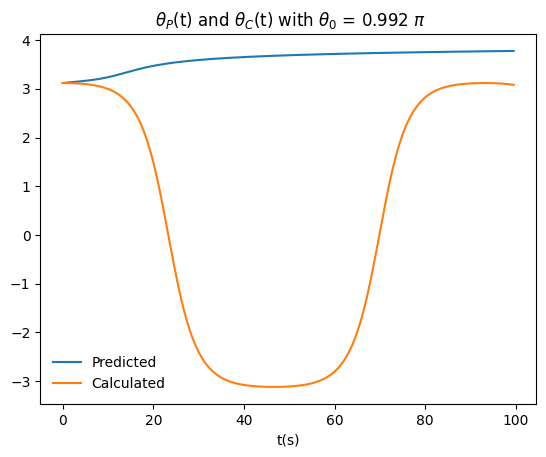

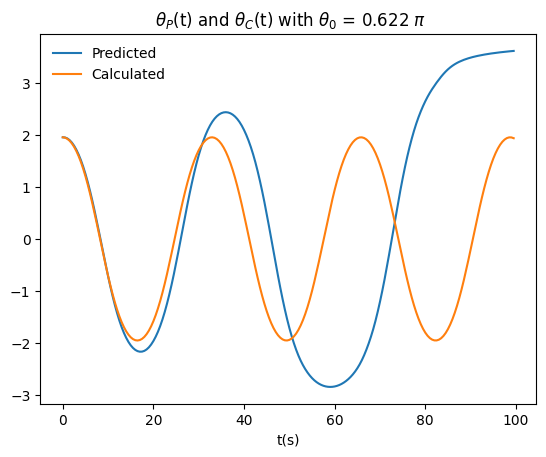

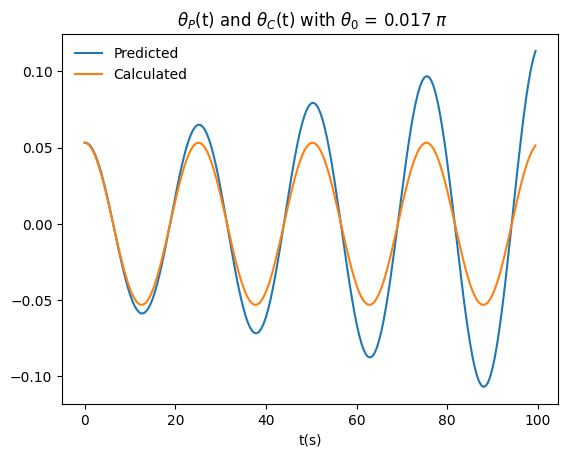

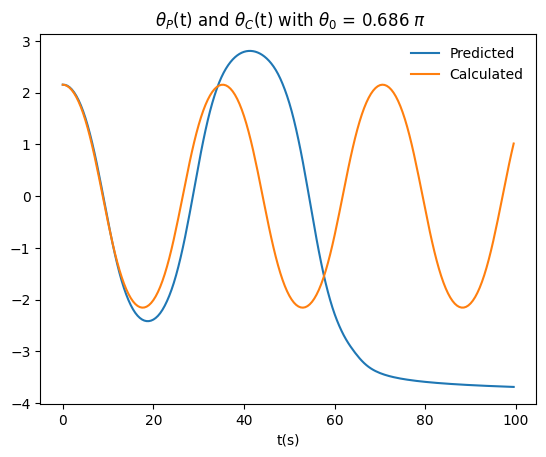

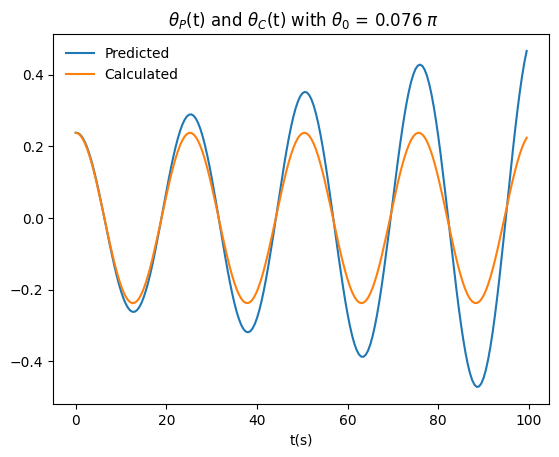

In [ ]:
#Plot test set for training set at lower sampling rate
for i in range(tn):
    trajs_M=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
    plt.plot(tt,trajs_M.y[0],label='Predicted')
    m=np.sin(testy_0[i,0]/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #parameter for each trajectory
    for j in range(np.size(tt)):
        trajs_A[j]=2*np.arcsin(np.sin(testy_0[i,0]/2)*sp.ellipj(K-omega_0*tt[j],(np.sin(testy_0[i,0]/2)**2))[0])
    plt.plot(tt,trajs_A,label='Calculated')
    plt.xlabel('t(s)')
    plt.legend(loc='best',frameon=False)
    theta_P = r"${\theta}_P$"
    theta_C = r"${\theta}_C$"
    testy=np.round(testy_0[i,0]/np.pi,3)
    theta0_str=f"{testy} $\pi$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
    plt.show()


    
                                                         

In [81]:
sol=np.zeros([tn,len(tt),d])
for i in range(tn):
#stop=2
#for i in range(stop):
  trajs=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i,:],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='LSODA',rtol=1e-14)
  #trajs = euler(fstar,y_0[i,:],tt[0],(tt[1]-tt[0])/2,100,Gmatrix,alpha,tt[1]-tt[0],d)
  #trajs= euler(fstar,y_0[i,:],tt[0],tt[1]-tt[0],len(tt),Gmatrix,alpha,tt[1]-tt[0],d)
  sol[i,:]=(trajs.y).T

In [30]:
stesty_0=np.sort(testy_0,axis=0)

array([[0.05323808, 0.        ],
       [0.23792941, 0.        ],
       [1.95417974, 0.        ],
       [2.15519758, 0.        ],
       [3.1178716 , 0.        ]])

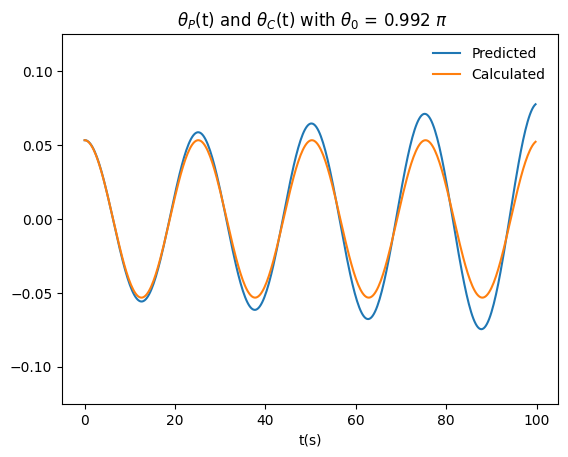

0.07756746346386262


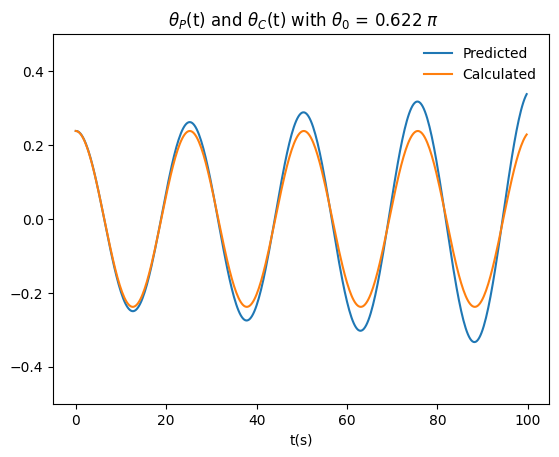

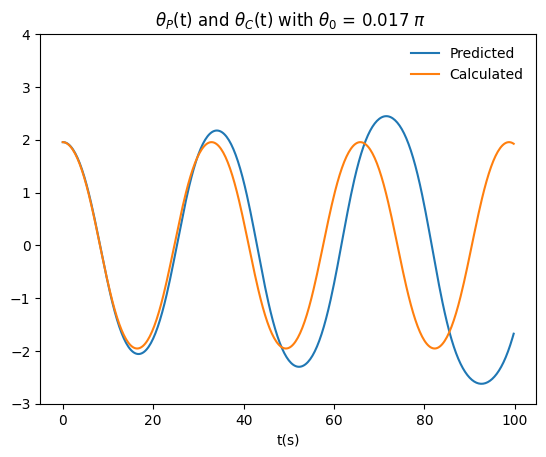

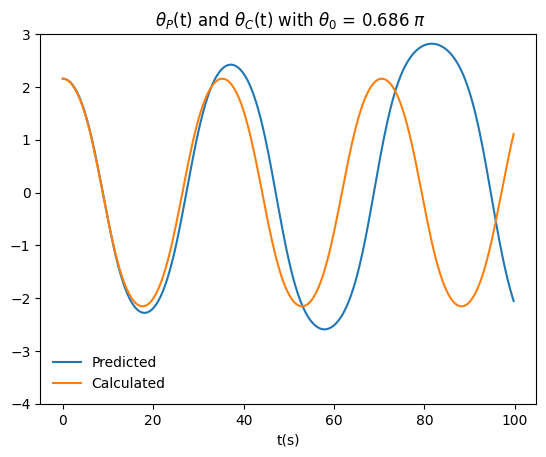

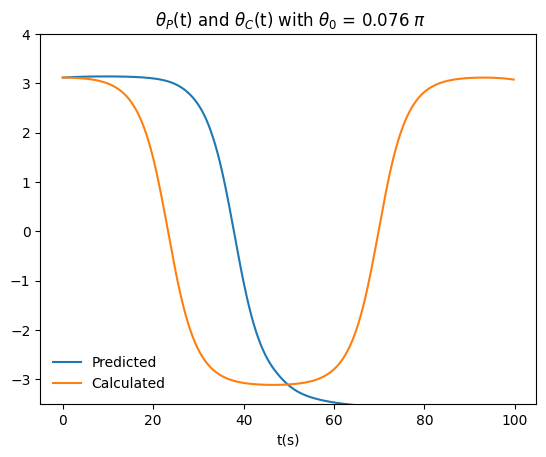

In [ ]:
#Plot test set for training set at ligher sampling rate
trajs_A=np.zeros(np.size(tt))
stesty_0=np.sort(testy_0,axis=0)
for i in range(tn):
    trajs_M=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=stesty_0[i],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
    plt.plot(tt,trajs_M.y[0],label='Predicted')
    m=np.sin(stesty_0[i,0]/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #parameter for each trajectory
    for j in range(np.size(tt)):
        trajs_A[j]=2*np.arcsin(np.sin(stesty_0[i,0]/2)*sp.ellipj(K-omega_0*tt[j],(np.sin(stesty_0[i,0]/2)**2))[0])
    plt.plot(tt,trajs_A,label='Calculated')
    plt.xlabel('t(s)')
    plt.legend(loc='best',frameon=False)
    theta_P = r"${\theta}_P$"
    theta_C = r"${\theta}_C$"
    testy=np.round(testy_0[i,0]/np.pi,3)
    theta0_str=f"{testy} $\pi$"
    #Allign plots with different sampling rates for slides
    if i==0:
        plt.ylim([-.125,.125])
    if i==1:
        plt.ylim([-.5,.5])
    if i==2:
        plt.ylim([-3,4])
    if i==3:
        plt.ylim([-4,3])
    if i==4:
        plt.ylim([-3.5,4])

    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
    plt.show()
    if i==0:
        print(trajs_M.y[0,-1])

